# Telco Customer Churn Prediction Using Machine Learning

## Objective

Predict customers who are likely to leave a telecom service using Machine Learning.

Models used:

- Decision Tree Classifier
- Logistic Regression

The project includes:
- Exploratory Data Analysis
- Data Preprocessing
- Model Training
- Model Comparison
- Feature Importance Analysis
- Business Recommendations

# Import Libraries

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

import warnings
warnings.filterwarnings("ignore")

# Load Dataset


In [31]:
df = pd.read_csv(
    "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Initial Data Inspection

In [32]:
df.shape

(7043, 21)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [34]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Data Cleaning

In [35]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

# Exploratory Data Analysis(EDA)

#  Churn Distribution

### Observation
The dataset is imbalanced.

Most customers did not churn, while a smaller percentage left the company.

therefore, accuracy alone is not enough to evaluate the model.
Precision, recall, and F1-score are also considered.

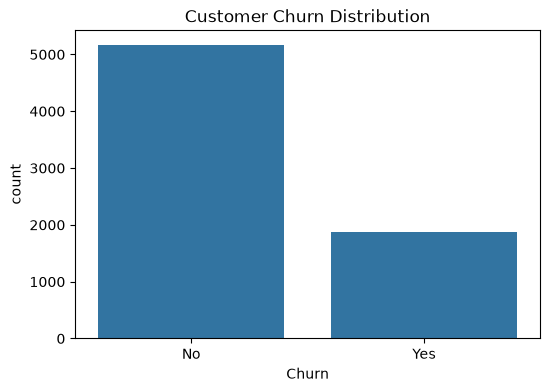

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title(
    "Customer Churn Distribution"
)

plt.show()

# Contract vs Churn

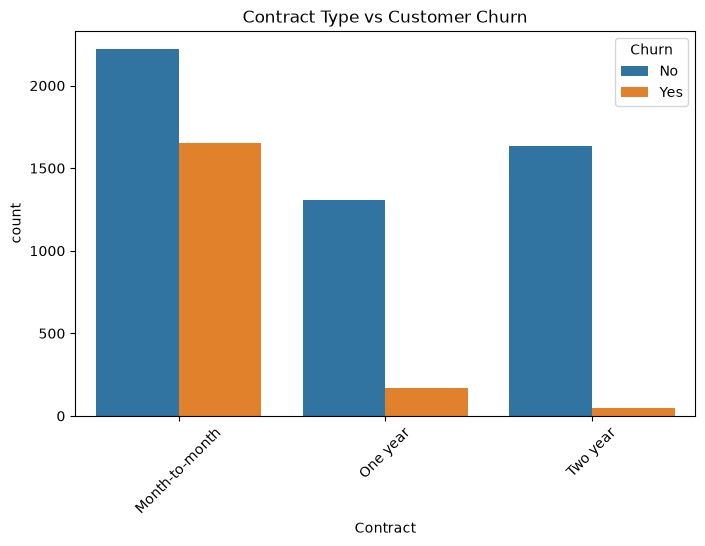

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)

plt.title(
    "Contract Type vs Customer Churn"
)

plt.show()

# Tenure Analysis


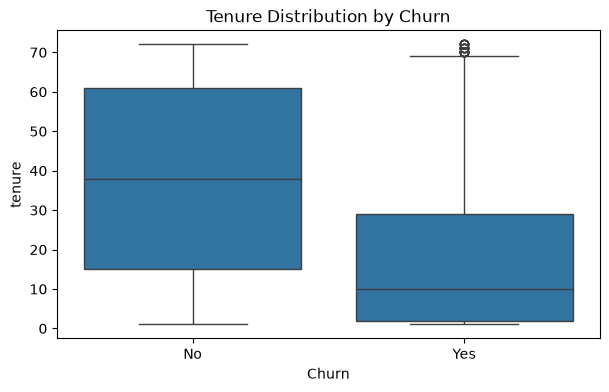

In [38]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title(
    "Tenure Distribution by Churn"
)

plt.show()

# Monthly Charges Analysis

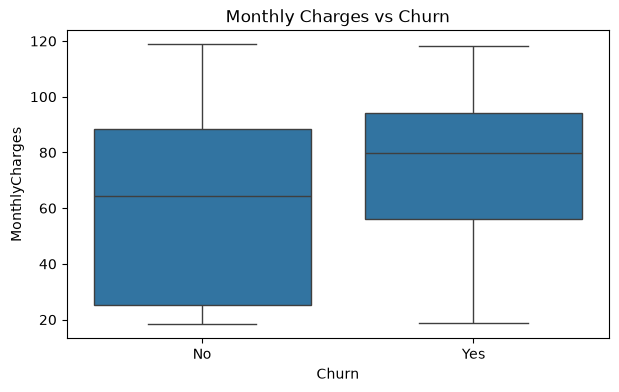

In [39]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title(
    "Monthly Charges vs Churn"
)

plt.show()

# Encode Categorical Variables

In [40]:
# Remove customer ID because it is only a unique identifier
df = df.drop("customerID", axis=1)

# Convert categorical variables into numerical variables
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


# Split Features and Target

In [41]:
X = df.drop(
    "Churn_Yes",
    axis=1
)


y = df["Churn_Yes"]

# Train Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [43]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# Class Balance Check

Before training the models, we check the distribution of the target variable. The churn class is the minority class, so accuracy alone may not reflect how well the model identifies customers who actually churn.

Class counts:
Churn_Yes
False    5163
True     1869
Name: count, dtype: int64

Class percentages:
Churn_Yes
False    73.42
True     26.58
Name: proportion, dtype: float64


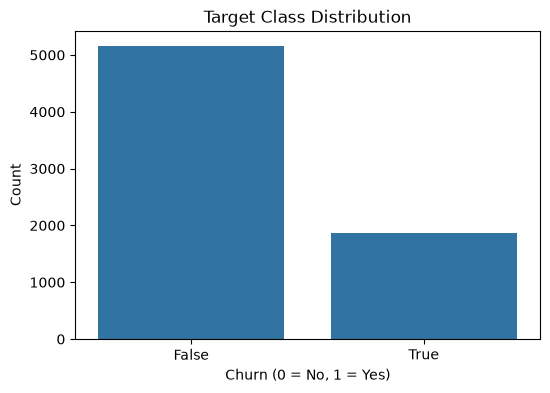

In [44]:
print("Class counts:")
print(y.value_counts())

print("\nClass percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Baseline Models — Before SMOTE

The baseline models are trained on the original imbalanced training data. No class weighting or oversampling is used here so that the effect of SMOTE can be compared fairly.

In [45]:
# Decision Tree baseline
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

dt_prediction = decision_tree.predict(X_test)

print("Decision Tree — Before SMOTE")
print(classification_report(y_test, dt_prediction))

Decision Tree — Before SMOTE
              precision    recall  f1-score   support

       False       0.81      0.81      0.81      1033
        True       0.47      0.46      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



In [46]:
# Logistic Regression baseline
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

lr_prediction = logistic_model.predict(X_test_scaled)

print("Logistic Regression — Before SMOTE")
print(classification_report(y_test, lr_prediction))

Logistic Regression — Before SMOTE
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1033
        True       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



# Handling Class Imbalance with SMOTE

SMOTE (Synthetic Minority Oversampling Technique) creates synthetic examples of the minority class. It is applied **only to the training data** so that the test set remains untouched and continues to represent unseen data.

In [47]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Training distribution before SMOTE:")
print(y_train.value_counts())

print("\nTraining distribution after SMOTE:")
print(y_train_smote.value_counts())

Training distribution before SMOTE:
Churn_Yes
False    4130
True     1495
Name: count, dtype: int64

Training distribution after SMOTE:
Churn_Yes
False    4130
True     4130
Name: count, dtype: int64


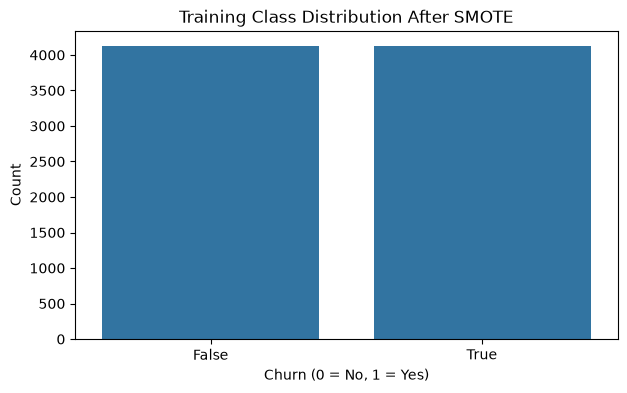

In [48]:
plt.figure(figsize=(7,4))
sns.countplot(x=y_train_smote)
plt.title("Training Class Distribution After SMOTE")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Retrain Models After SMOTE

The models are retrained using the balanced training data. The original test set is used for evaluation.

In [49]:
# Scale the SMOTE-balanced training data for Logistic Regression
smote_scaler = StandardScaler()

X_train_smote_scaled = smote_scaler.fit_transform(X_train_smote)
X_test_smote_scaled = smote_scaler.transform(X_test)

# Decision Tree after SMOTE
decision_tree_smote = DecisionTreeClassifier(random_state=42)
decision_tree_smote.fit(X_train_smote, y_train_smote)

dt_smote_prediction = decision_tree_smote.predict(X_test)

print("Decision Tree — After SMOTE")
print(classification_report(y_test, dt_smote_prediction))

Decision Tree — After SMOTE
              precision    recall  f1-score   support

       False       0.82      0.79      0.80      1033
        True       0.47      0.52      0.49       374

    accuracy                           0.72      1407
   macro avg       0.64      0.65      0.65      1407
weighted avg       0.73      0.72      0.72      1407



In [50]:
# Logistic Regression after SMOTE
logistic_model_smote = LogisticRegression(max_iter=1000)
logistic_model_smote.fit(X_train_smote_scaled, y_train_smote)

lr_smote_prediction = logistic_model_smote.predict(X_test_smote_scaled)

print("Logistic Regression — After SMOTE")
print(classification_report(y_test, lr_smote_prediction))

Logistic Regression — After SMOTE
              precision    recall  f1-score   support

       False       0.86      0.81      0.84      1033
        True       0.55      0.65      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.77      1407



# Before vs After SMOTE Comparison

Precision, Recall, and F1-score are compared because they provide more useful information than accuracy alone for an imbalanced classification problem.

In [51]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree", "Decision Tree",
        "Logistic Regression", "Logistic Regression"
    ],
    "Approach": [
        "Before SMOTE", "After SMOTE",
        "Before SMOTE", "After SMOTE"
    ],
    "Accuracy": [
        accuracy_score(y_test, dt_prediction),
        accuracy_score(y_test, dt_smote_prediction),
        accuracy_score(y_test, lr_prediction),
        accuracy_score(y_test, lr_smote_prediction)
    ],
    "Precision": [
        precision_score(y_test, dt_prediction),
        precision_score(y_test, dt_smote_prediction),
        precision_score(y_test, lr_prediction),
        precision_score(y_test, lr_smote_prediction)
    ],
    "Recall": [
        recall_score(y_test, dt_prediction),
        recall_score(y_test, dt_smote_prediction),
        recall_score(y_test, lr_prediction),
        recall_score(y_test, lr_smote_prediction)
    ],
    "F1 Score": [
        f1_score(y_test, dt_prediction),
        f1_score(y_test, dt_smote_prediction),
        f1_score(y_test, lr_prediction),
        f1_score(y_test, lr_smote_prediction)
    ]
})

comparison.round(4)

,Model,Approach,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,Before SMOTE,0.7186,0.4701,0.4626,0.4663
1,Decision Tree,After SMOTE,0.7157,0.4684,0.5160,0.4911
2,Logistic Regression,Before SMOTE,0.8038,0.6476,0.5749,0.6091
3,Logistic Regression,After SMOTE,0.7662,0.5513,0.6471,0.5953


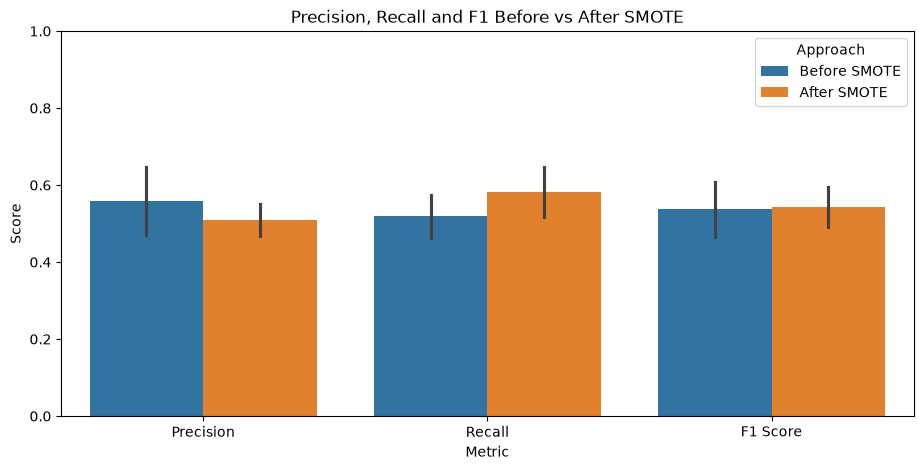

In [52]:
comparison_plot = comparison.melt(
    id_vars=["Model", "Approach"],
    value_vars=["Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=comparison_plot,
    x="Metric",
    y="Score",
    hue="Approach"
)

plt.title("Precision, Recall and F1 Before vs After SMOTE")
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Approach")

plt.show()

# Why Accuracy Can Be Misleading

The Telco Customer Churn dataset is imbalanced because there are many more customers who did not churn than customers who churned. A model can therefore obtain a relatively high accuracy by favoring the majority class while still missing a substantial number of actual churn customers.

For this reason, Precision, Recall, and F1-score are important when evaluating the minority churn class. Recall is especially useful when the goal is to identify as many actual churn customers as possible. SMOTE increases representation of the minority class in the training data, allowing the models to learn from a more balanced set of examples.

The test data is not resampled, so the final evaluation is performed on the original distribution.

# Conclusion

This experiment demonstrated the effect of class imbalance on customer churn prediction. A baseline was first trained on the original imbalanced training data. SMOTE was then applied only to the training set, and both models were retrained.

The final comparison of Precision, Recall, and F1-score shows how balancing the training data changes minority-class performance. The best model should be selected based on the business objective rather than accuracy alone.

# Confusion Matrix

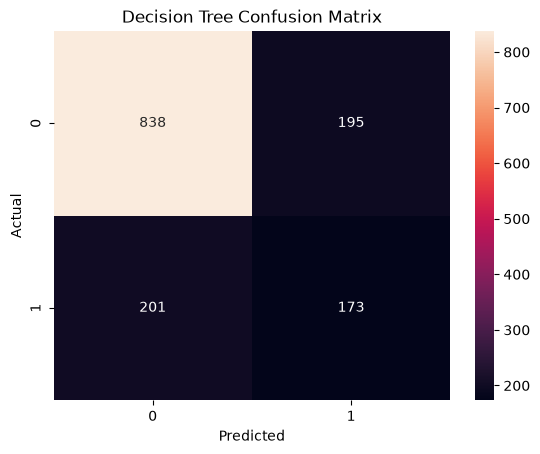

In [53]:
cm = confusion_matrix(
    y_test,
    dt_prediction
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()


# Feature Importance

In [54]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    decision_tree_smote.feature_importances_

})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


feature_importance.head(10)

,Feature,Importance
28,PaymentMethod_Electronic check,0.222619
1,tenure,0.172812
2,MonthlyCharges,0.146577
3,TotalCharges,0.133610
10,InternetService_Fiber optic,0.066635
26,PaperlessBilling_Yes,0.028543
4,gender_Male,0.021574
27,PaymentMethod_Credit card (automatic),0.021214
9,MultipleLines_Yes,0.019072
0,SeniorCitizen,0.016903


# Top 10 Feature Visualization

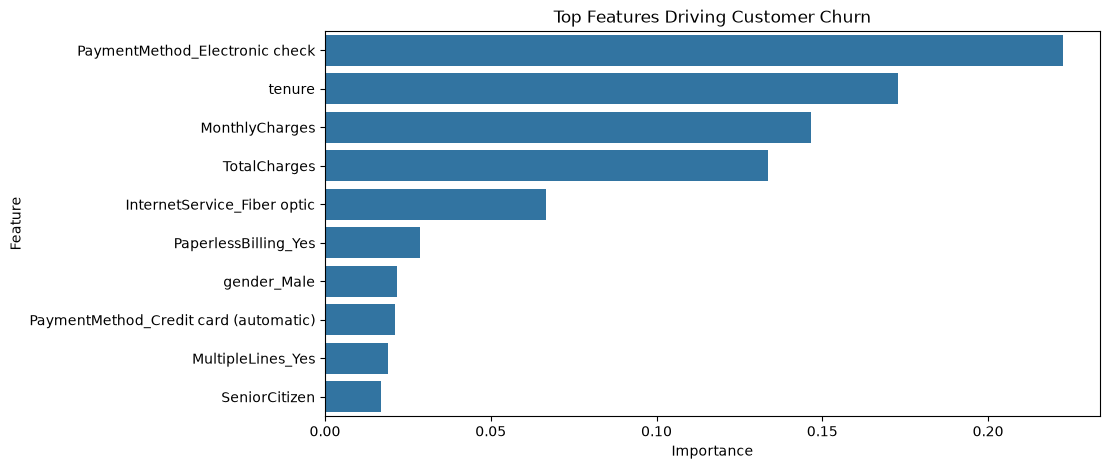

In [55]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features Driving Customer Churn"
)

plt.show()

# Save Models

In [58]:
import os
import joblib

# Create models folder
os.makedirs("../models", exist_ok=True)

# Save the SMOTE-trained Logistic Regression model
joblib.dump(
    logistic_model_smote,
    "../models/churn_model.pkl"
)

# Save the scaler used for Logistic Regression
joblib.dump(
    smote_scaler,
    "../models/churn_scaler.pkl"
)

# Save the feature names used during training
joblib.dump(
    X.columns.tolist(),
    "../models/churn_features.pkl"
)

print("Deployment files saved successfully!")

Deployment files saved successfully!


In [60]:
print("Number of features:", len(X.columns))
print("\nFeatures:")
for feature in X.columns:
    print(feature)

Number of features: 30

Features:
SeniorCitizen
tenure
MonthlyCharges
TotalCharges
gender_Male
Partner_Yes
Dependents_Yes
PhoneService_Yes
MultipleLines_No phone service
MultipleLines_Yes
InternetService_Fiber optic
InternetService_No
OnlineSecurity_No internet service
OnlineSecurity_Yes
OnlineBackup_No internet service
OnlineBackup_Yes
DeviceProtection_No internet service
DeviceProtection_Yes
TechSupport_No internet service
TechSupport_Yes
StreamingTV_No internet service
StreamingTV_Yes
StreamingMovies_No internet service
StreamingMovies_Yes
Contract_One year
Contract_Two year
PaperlessBilling_Yes
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check
